# Additional figures

Five methods (Fisher, ALICE, TCRnet, tcrdist3, REDCEA) compared on the same
shared candidate list and the same held-out donors, plus a motif-level
analysis of what the significant clonotypes actually look like.

```
PREPARED_DIR   -- scripts/01_prepare_data.py's output
                  (case/control corrected repertoires, candidates.tsv,
                   test_*_repertoire_corrected.tsv, metadata_split.csv)
RESULTS_DIR    -- scripts/run_all.sh's output
                  (fisher_result.tsv, alice_result.tsv, tcrnet_result.tsv,
                   tcrdist3_result.tsv)
REDCEA_DIR     -- redcea/run_redcea.sh's output
                  (*_summary_tcrempnet.tsv, *_tcremp_clusters.tsv)
```

## Contents
1. Motivating the train/test split
2. Loading results from all five methods
3. Method comparison: hit counts, recall/FPR on held-out donors
4. Clustering significant clonotypes together with known COVID biomarkers, motif analysis
5. Conclusions template


## 0. Setup

In [53]:
!pip -q install pandas numpy scipy matplotlib seaborn networkx matplotlib-venn upsetplot requests


In [54]:
import glob
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

PREPARED_DIR = Path("./prepared_data")   # scripts/01_prepare_data.py output, copied here
RESULTS_DIR = Path("./method_results")   # scripts/run_all.sh output, copied here
REDCEA_DIR = Path("./redcea_results")    # redcea/run_redcea.sh output, copied here

SEED = 42


## 1. Motivating the train/test split

The candidate list (`candidates.tsv`) was built by requiring a clonotype to
appear in >=3 **train** COVID donors. If we then asked "what fraction of
donors carry a significant clonotype" using those *same* train donors, the
answer would be inflated by construction -- some of those donors are the
reason the clonotype became a candidate in the first place. The held-out test
donors never contributed to candidate selection, batch-correction fitting, or
any method's discovery step; comparing the two directly makes the case for
why the split exists, rather than just asserting it.


In [55]:
metadata = pd.read_csv(PREPARED_DIR / "metadata_split.csv")
print(metadata.groupby(["split", "COVID_status"]).size().unstack(fill_value=0))

train_case = pd.read_csv(PREPARED_DIR / "case_repertoire_corrected.tsv", sep="\t")
test_case = pd.read_csv(PREPARED_DIR / "test_case_repertoire_corrected.tsv", sep="\t")
test_control = pd.read_csv(PREPARED_DIR / "test_control_repertoire_corrected.tsv", sep="\t")
candidates = pd.read_csv(PREPARED_DIR / "candidates.tsv", sep="\t")
print(f"\ncandidates.tsv: {len(candidates)} clonotypes")


COVID_status  COVID  healthy
split                       
test            153       91
train           695      285

candidates.tsv: 11774 clonotypes


In [56]:
def has_neighbor(query_list, representative_list, max_hamming=1):
    rep_by_len = {}
    for r in representative_list:
        rep_by_len.setdefault(len(r), []).append(r)
    out = []
    for q in query_list:
        reps = rep_by_len.get(len(q), [])
        out.append(any(sum(x != y for x, y in zip(q, r)) <= max_hamming for r in reps))
    return np.array(out)

def donor_level_rate(repertoire_df, representatives, seq_col="junction_aa"):
    if not representatives:
        return np.nan
    return np.mean([
        has_neighbor(d[seq_col].tolist(), representatives).any()
        for _, d in repertoire_df.groupby("sample_id")
    ])

# use the raw candidate list itself as a stand-in "marker set" purely to
# illustrate the train-vs-test inflation effect (not a real method's output)
candidate_seqs = candidates["junction_aa"].unique().tolist()

train_case_sample_ids = train_case["sample_id"].unique()
rng = np.random.default_rng(SEED)
train_subset_ids = rng.choice(train_case_sample_ids, size=min(len(test_case["sample_id"].unique()), len(train_case_sample_ids)), replace=False)
train_case_subset = train_case[train_case["sample_id"].isin(train_subset_ids)]

train_detection = donor_level_rate(train_case_subset, candidate_seqs)
test_detection = donor_level_rate(test_case, candidate_seqs)

print(f"Fraction of TRAIN COVID donors carrying a candidate clonotype: {train_detection:.3f}")
print(f"Fraction of TEST COVID donors carrying a candidate clonotype:  {test_detection:.3f}")
print("\n(train is inflated by construction -- those donors helped define the candidate list;"
      "\nonly the test number is an honest estimate of generalisation)")


Fraction of TRAIN COVID donors carrying a candidate clonotype: 1.000
Fraction of TEST COVID donors carrying a candidate clonotype:  1.000

(train is inflated by construction -- those donors helped define the candidate list;
only the test number is an honest estimate of generalisation)


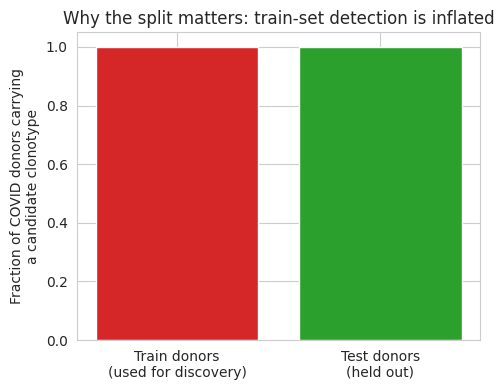

In [57]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Train donors\n(used for discovery)", "Test donors\n(held out)"],
       [train_detection, test_detection], color=["#d62728", "#2ca02c"])
ax.set_ylabel("Fraction of COVID donors carrying\na candidate clonotype")
ax.set_title("Why the split matters: train-set detection is inflated")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


## 2. Loading results from all five methods

In [58]:
fisher_df = pd.read_csv(RESULTS_DIR / "fisher_result.tsv", sep="\t")
alice_df = pd.read_csv(RESULTS_DIR / "alice_result.tsv", sep="\t")
tcrnet_df = pd.read_csv(RESULTS_DIR / "tcrnet_result.tsv", sep="\t")
tcrdist3_df = pd.read_csv(RESULTS_DIR / "tcrdist3_result.tsv", sep="\t")

print("Fisher:  ", fisher_df.shape, list(fisher_df.columns))
print("ALICE:   ", alice_df.shape, list(alice_df.columns))
print("TCRnet:  ", tcrnet_df.shape, list(tcrnet_df.columns))
print("tcrdist3:", tcrdist3_df.shape, list(tcrdist3_df.columns))

fisher_hits = fisher_df.loc[fisher_df["fdr_shared"] < 0.05, "junction_aa"].dropna().unique().tolist()
alice_hits = alice_df.loc[alice_df["fdr_shared"] < 0.05, "junction_aa"].dropna().unique().tolist()
tcrnet_hits = tcrnet_df.loc[tcrnet_df["fdr_shared"] < 0.05, "junction_aa"].dropna().unique().tolist()
tcrdist3_hits = tcrdist3_df.loc[tcrdist3_df["fdr_shared"] < 0.05, "cdr3_b_aa"].dropna().unique().tolist()

print(f"\nSignificant (shared FDR<0.05): Fisher={len(fisher_hits)}, ALICE={len(alice_hits)}, "
      f"TCRnet={len(tcrnet_hits)}, tcrdist3={len(tcrdist3_hits)}")


Fisher:   (11774, 20) ['junction_aa', 'v_call', 'j_call', 'incidence', 'n_pos_present', 'n_neg_present', 'n_pos', 'n_neg', 'odds_ratio', 'log2_or', 'direction', 'test', 'p_value', 'q_value', 'logor', 'logor_ci_lo', 'logor_ci_hi', 'p_or_gt1', 'log_bf', 'fdr_shared']
ALICE:    (11759, 12) ['junction_aa', 'v_call', 'j_call', 'duplicate_count', 'n_neighbors', 'n_group', 'pgen_ball', 'E', 'p_enrichment', 'q_value', 'locus', 'fdr_shared']
TCRnet:   (2504, 12) ['junction_aa', 'v_call', 'j_call', 'duplicate_count', 'n_neighbors', 'n_control', 'E', 'p_enrichment', 'q_value', 'p_any', 'locus', 'fdr_shared']
tcrdist3: (11774, 7) ['cdr3_b_aa', 'v_b_gene', 'j_b_gene', 'n_case_neighbors', 'n_control_neighbors', 'p_value', 'fdr_shared']

Significant (shared FDR<0.05): Fisher=0, ALICE=4342, TCRnet=12, tcrdist3=0


In [59]:
# REDCEA: cluster-level, not clonotype-level -- load both files and expand
# to per-clonotype membership of significant clusters
redcea_summary_path = glob.glob(str(REDCEA_DIR / "*_summary_tcrempnet.tsv"))[0]
redcea_clusters_path = glob.glob(str(REDCEA_DIR / "*_tcremp_clusters.tsv"))[0]

redcea_summary = pd.read_csv(redcea_summary_path, sep="\t")
redcea_clusters = pd.read_csv(redcea_clusters_path, sep="\t")
print("REDCEA summary columns:", list(redcea_summary.columns))
print("REDCEA clusters columns:", list(redcea_clusters.columns))

sig_cluster_ids = set(redcea_summary.loc[redcea_summary["enrichment_fdr_zbinom"] < 0.05, "cluster_id"])
seq_col_redcea = next(c for c in redcea_clusters.columns if "cdr3" in c.lower())
redcea_hits = redcea_clusters.loc[
    redcea_clusters["cluster_id"].isin(sig_cluster_ids), seq_col_redcea
].dropna().unique().tolist()
print(f"REDCEA: {len(sig_cluster_ids)} significant clusters, {len(redcea_hits)} member clonotypes")


REDCEA summary columns: ['cluster_id', 'cluster_size', 'sample', 'background', 'enrichment_pvalue_zbinom', 'enrichment_fdr_zbinom', 'log_fold_change']
REDCEA clusters columns: ['clone_id', 'cluster_id', 'cdr3aa_TRB', 'v_TRB', 'j_TRB']
REDCEA: 246 significant clusters, 2808 member clonotypes


## 3. Method comparison

In [60]:
methods = {
    "Fisher": fisher_hits,
    "ALICE": alice_hits,
    "TCRnet": tcrnet_hits,
    "tcrdist3": tcrdist3_hits,
    "REDCEA": redcea_hits,
}

rows = []
for name, reps in methods.items():
    recall = donor_level_rate(test_case, reps)
    fpr = donor_level_rate(test_control, reps)
    rows.append({"Method": name, "Significant clonotypes": len(reps),
                 "Recall (test COVID)": recall, "FPR (test healthy)": fpr})

comparison_table = pd.DataFrame(rows).sort_values("Recall (test COVID)", ascending=False)
comparison_table


,Method,Significant clonotypes,Recall (test COVID),FPR (test healthy)
1,ALICE,4342,1.000000,1.000000
4,REDCEA,2808,1.000000,1.000000
2,TCRnet,12,0.267974,0.153846
0,Fisher,0,NaN,NaN
3,tcrdist3,0,NaN,NaN


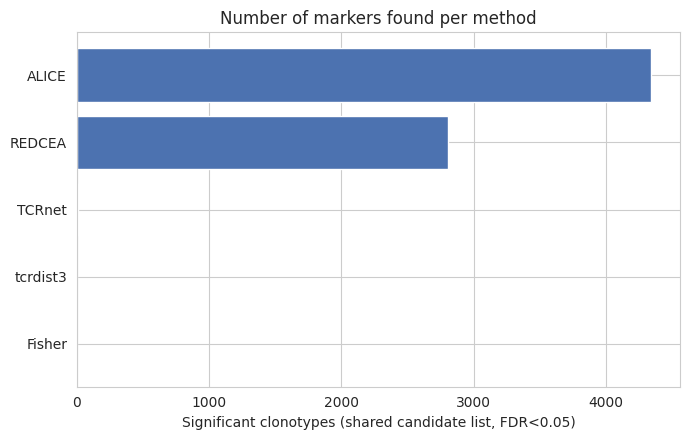

In [61]:
fig, ax = plt.subplots(figsize=(7, 4.5))
order = comparison_table.sort_values("Significant clonotypes")
ax.barh(order["Method"], order["Significant clonotypes"], color="#4C72B0")
ax.set_xlabel("Significant clonotypes (shared candidate list, FDR<0.05)")
ax.set_title("Number of markers found per method")
plt.tight_layout()
plt.show()


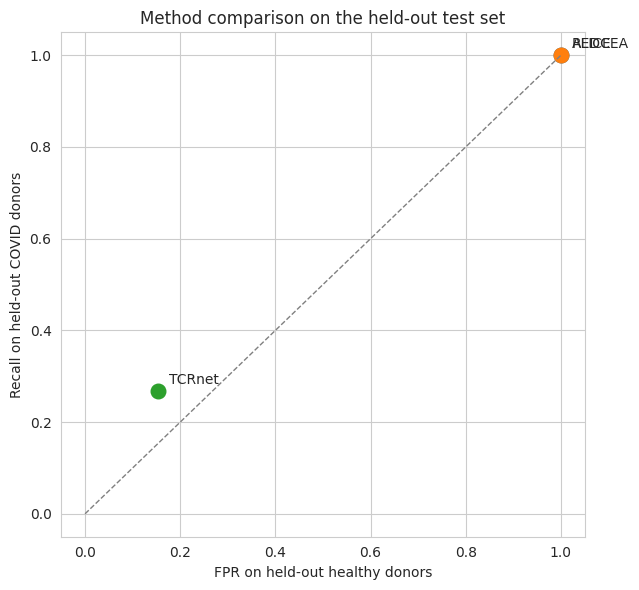

In [62]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for _, row in comparison_table.iterrows():
    ax.scatter(row["FPR (test healthy)"], row["Recall (test COVID)"], s=110)
    ax.annotate(row["Method"], (row["FPR (test healthy)"], row["Recall (test COVID)"]),
                textcoords="offset points", xytext=(8, 5))
ax.plot([0, 1], [0, 1], "--", color="grey", linewidth=1)
ax.set_xlabel("FPR on held-out healthy donors")
ax.set_ylabel("Recall on held-out COVID donors")
ax.set_title("Method comparison on the held-out test set")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()


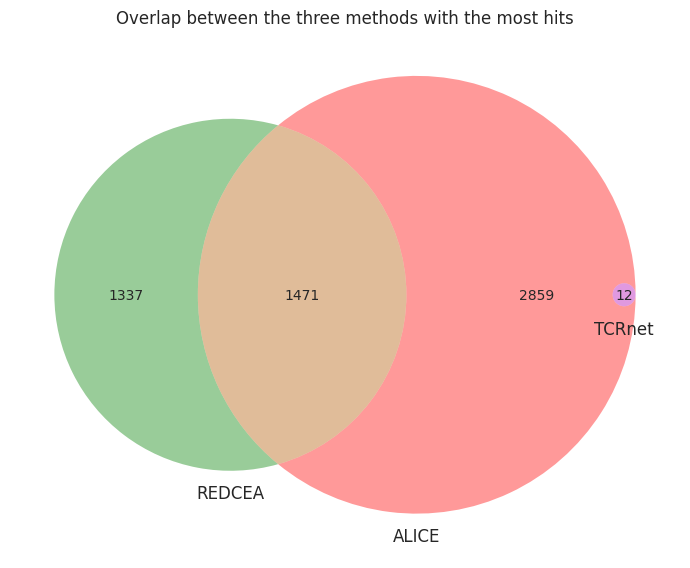

In [63]:
from matplotlib_venn import venn3

top3 = comparison_table.sort_values("Significant clonotypes", ascending=False)["Method"].head(3).tolist()
sets_top3 = [set(methods[name]) for name in top3]

fig, ax = plt.subplots(figsize=(7, 7))
venn3(sets_top3, set_labels=top3, ax=ax)
ax.set_title("Overlap between the three methods with the most hits")
plt.tight_layout()
plt.show()


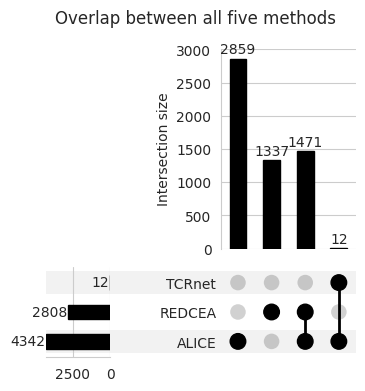

In [64]:
from upsetplot import UpSet, from_contents

contents = {name: set(reps) for name, reps in methods.items() if reps}
upset_data = from_contents(contents)

fig = plt.figure(figsize=(10, 6))
UpSet(upset_data, subset_size="count", show_counts=True).plot(fig=fig)
plt.suptitle("Overlap between all five methods")
plt.show()


## 4. Clustering significant clonotypes with known COVID biomarkers

Pool every method's significant clonotypes together with the dataset's own
published biomarker list (`covid_clonotypes.csv`), cluster the whole pool by
CDR3 similarity (Hamming distance <=1, same length -- a lightweight,
dependency-free graph clustering; connected components via `networkx`), and
look at which clusters mix method-hits with a *known* biomarker, versus
clusters that are method-only or known-biomarker-only.


In [65]:
import requests

ZENODO_RECORD = "17780804"
gt_path = PREPARED_DIR.parent / "covid_clonotypes.csv"
if not gt_path.exists():
    url = f"https://zenodo.org/api/records/{ZENODO_RECORD}/files/covid_clonotypes.csv/content"
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    gt_path.write_bytes(r.content)

ground_truth = pd.read_csv(gt_path)
known_biomarkers = ground_truth.loc[
    (ground_truth["chain"] == "TRB") & (ground_truth["has_covid_association"].astype(bool)), "cdr3"
].dropna().unique().tolist()
print(f"Known published biomarkers (TRB): {len(known_biomarkers)}")


Known published biomarkers (TRB): 0


In [72]:
import requests

ZENODO_RECORD = "17780804"
gt_path = PREPARED_DIR.parent / "covid_clonotypes.csv"
if not gt_path.exists():
    url = f"https://zenodo.org/api/records/{ZENODO_RECORD}/files/covid_clonotypes.csv/content"
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    gt_path.write_bytes(r.content)

ground_truth = pd.read_csv(gt_path)
print(ground_truth.shape)
print(ground_truth.columns.tolist())
print("chain values:", ground_truth["chain"].unique())
print("has_covid_association values:", ground_truth["has_covid_association"].unique())
print(ground_truth.head(10))

known_biomarkers = ground_truth.loc[
    (ground_truth["chain"] == "beta") & (ground_truth["has_covid_association"].astype(bool)), "cdr3"
].dropna().unique().tolist()
print(f"Known published biomarkers (TRB/beta): {len(known_biomarkers)}")

(4960, 6)
['cdr3', 'cluster', 'has_covid_association', 'chain', 'v', 'j']
chain values: ['beta' 'alpha']
has_covid_association values: [False  True]
            cdr3  cluster  has_covid_association chain  \
0  CASAPGGSYEQYF        0                  False  beta   
1  CASIPGGSYEQYF        0                  False  beta   
2  CASKPGGSYEQYF        0                  False  beta   
3  CASLPGGSYEQYF        0                  False  beta   
4  CASNPGGSYEQYF        0                  False  beta   
5  CASRPGGSYEQYF        0                  False  beta   
6  CASSPGGSYEQYF        0                  False  beta   
7  CASKLGTSYEQYF        0                  False  beta   
8  CASRLGTSYEQYF        0                  False  beta   
9  CASSLGTSYEQYF        0                  False  beta   

                                      v        j  
0               TRBV12-5/TRBV7-9/TRBV28  TRBJ2-7  
1                               TRBV6-5  TRBJ2-7  
2              TRBV5-4/TRBV25-1/TRBV6-5  TRBJ2-7  
3       

In [73]:
# pool: every sequence, tagged by which source(s) it came from
pool = {}
for name, reps in methods.items():
    for seq in reps:
        pool.setdefault(seq, set()).add(name)
for seq in known_biomarkers:
    pool.setdefault(seq, set()).add("known_biomarker")

pool_seqs = list(pool.keys())
print(f"Pool size (union of all method hits + known biomarkers): {len(pool_seqs)}")


Pool size (union of all method hits + known biomarkers): 5713


In [74]:
def build_hamming1_graph(seqs, max_hamming=1):
    g = nx.Graph()
    g.add_nodes_from(seqs)
    by_len = {}
    for s in seqs:
        by_len.setdefault(len(s), []).append(s)
    for length, group in by_len.items():
        for i in range(len(group)):
            for j in range(i + 1, len(group)):
                a, b = group[i], group[j]
                if sum(x != y for x, y in zip(a, b)) <= max_hamming:
                    g.add_edge(a, b)
    return g

graph = build_hamming1_graph(pool_seqs)
clusters = [c for c in nx.connected_components(graph) if len(c) > 1]  # drop singletons
print(f"{len(clusters)} clusters with >1 member (out of {len(pool_seqs)} pooled sequences)")


28 clusters with >1 member (out of 5713 pooled sequences)


In [75]:
def consensus_motif(seqs):
    """Position-wise consensus for same-length sequences; '.' marks a
    position with no majority amino acid (i.e. genuinely variable)."""
    lengths = Counter(len(s) for s in seqs)
    common_len, _ = lengths.most_common(1)[0]
    same_len = [s for s in seqs if len(s) == common_len]
    if len(same_len) < 2:
        return seqs[0] if seqs else ""
    motif = []
    for pos in range(common_len):
        aas = Counter(s[pos] for s in same_len)
        aa, count = aas.most_common(1)[0]
        motif.append(aa if count / len(same_len) >= 0.5 else ".")
    return "".join(motif)

cluster_rows = []
for members in clusters:
    sources = set()
    for m in members:
        sources |= pool[m]
    cluster_rows.append({
        "cluster_size": len(members),
        "sources": ", ".join(sorted(sources)),
        "includes_known_biomarker": "known_biomarker" in sources,
        "n_methods_represented": len(sources - {"known_biomarker"}),
        "motif": consensus_motif(list(members)),
        "example_members": ", ".join(list(members)[:4]),
    })

clusters_df = pd.DataFrame(cluster_rows).sort_values(
    ["includes_known_biomarker", "n_methods_represented", "cluster_size"], ascending=False
)
print(f"Clusters containing a known biomarker: {clusters_df['includes_known_biomarker'].sum()} of {len(clusters_df)}")
clusters_df.head(20)


Clusters containing a known biomarker: 5 of 28


,cluster_size,sources,includes_known_biomarker,n_methods_represented,motif,example_members
0,856,"ALICE, REDCEA, TCRnet, known_biomarker",True,3,CASS..YEQYF,"CASSQAYEQFF, CAWRASYEQYF, CASSLHTEAFF, CAISDSY..."
10,112,"ALICE, REDCEA, TCRnet, known_biomarker",True,3,CSA..SYEQYF,"CSARLSYEQYF, CSASYSYEQYF, CRARSSYEQYF, CSASSDY..."
2,1090,"ALICE, REDCEA, known_biomarker",True,2,CASS...YEQYF,"CASSLRGYEQYF, CASSYVSYEQYF, CASSVGGSEQYF, CASS..."
5,108,"ALICE, REDCEA, known_biomarker",True,2,CASS.GGGTEAFF,"CASSRGVGTEAFF, CASSARQGTEAFF, CASSAGGGTEAFF, C..."
17,9,"ALICE, known_biomarker",True,1,CASSLDGAANEKLFF,"CASSLDGAANEKLFF, CASSLGGAANEKLFF, CASSLDGAVNEK..."
1,2147,"ALICE, REDCEA, TCRnet",False,3,CASS.G..YEQYF,"CASSPLRGYEQYF, CASSEGGLYEQYF, CASSLGQNYEQYF, C..."
3,855,"ALICE, REDCEA",False,2,CASS.G.GSYEQYF,"CASSPGTGFYEQYF, CASSLEQSSYEQYF, CASSVGTGAYEQYF..."
9,79,"ALICE, REDCEA",False,2,CASS.GTSGSYEQYF,"CASSPGTLGSYEQYF, CASSLGTSGIYEQYF, CASSRGTSGSYE..."
8,76,"ALICE, REDCEA",False,2,CASSPGGMNTEAFF,"CASSPPGMNTEAFF, CASSEGGMNTEAFF, CASSPGVLNTEAFF..."
4,75,"ALICE, REDCEA",False,2,CASSLG.NQPQHF,"CASRLGGNQPQHF, CASSTGLNQPQHF, CASSLRYNQPQHF, C..."


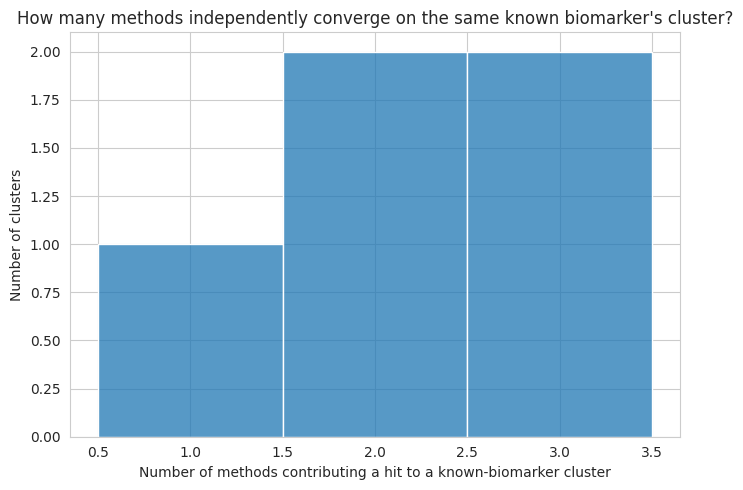

In [76]:
fig, ax = plt.subplots(figsize=(7, 5))
mixed = clusters_df[clusters_df["includes_known_biomarker"]]
sns.histplot(mixed["n_methods_represented"], bins=range(0, 6), ax=ax, discrete=True)
ax.set_xlabel("Number of methods contributing a hit to a known-biomarker cluster")
ax.set_ylabel("Number of clusters")
ax.set_title("How many methods independently converge on the same known biomarker's cluster?")
plt.tight_layout()
plt.show()


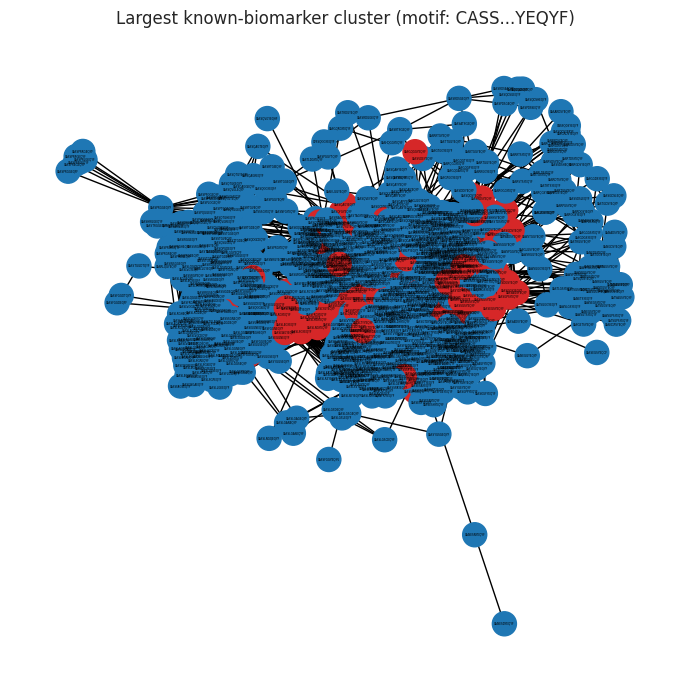

In [81]:
# a small visual: the largest known-biomarker cluster's neighbourhood graph
if len(mixed):
    biggest = mixed.sort_values("cluster_size", ascending=False).iloc[0]
    members = next(c for c in clusters if consensus_motif(list(c)) == biggest["motif"] and len(c) == biggest["cluster_size"])
    subgraph = graph.subgraph(members)

    fig, ax = plt.subplots(figsize=(7, 7))
    pos = nx.spring_layout(subgraph, seed=SEED)
    colors = ["#d62728" if "known_biomarker" in pool[n] else "#1f77b4" for n in subgraph.nodes]
    nx.draw_networkx(subgraph, pos, ax=ax, node_color=colors, node_size=300, font_size=2)
    ax.set_title(f"Largest known-biomarker cluster (motif: {biggest['motif']})")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No cluster currently mixes a method hit with a known biomarker -- nothing to plot.")


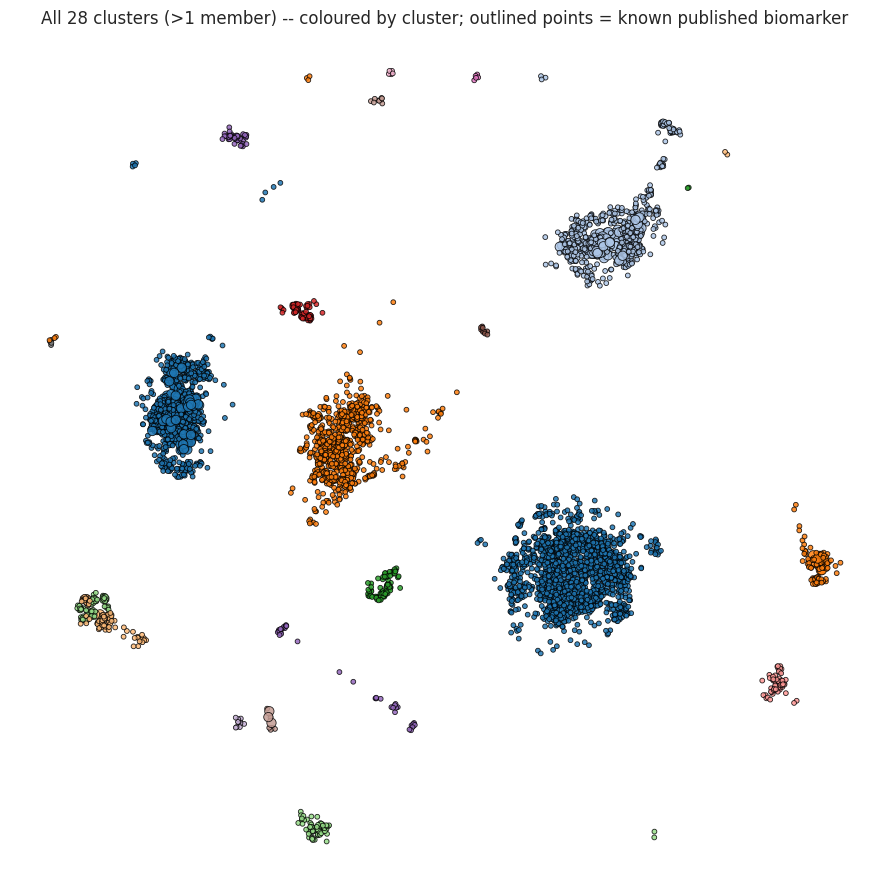

In [80]:
clustered_nodes = set()
for c in clusters:
    clustered_nodes |= c
subgraph_all = graph.subgraph(clustered_nodes)

pos_all = nx.spring_layout(subgraph_all, seed=SEED, k=0.15)

import matplotlib.cm as cm
cluster_list_sorted = sorted(clusters, key=len, reverse=True)
cmap = cm.get_cmap("tab20", max(len(cluster_list_sorted), 1))

node_color, node_is_known = {}, {}
for i, members in enumerate(cluster_list_sorted):
    color = cmap(i % 20)
    for m in members:
        node_color[m] = color
        node_is_known[m] = "known_biomarker" in pool[m]

xs = [pos_all[n][0] for n in subgraph_all.nodes]
ys = [pos_all[n][1] for n in subgraph_all.nodes]
colors = [node_color[n] for n in subgraph_all.nodes]
sizes = [45 if node_is_known[n] else 12 for n in subgraph_all.nodes]
edgecolors = ["black" if node_is_known[n] else "none" for n in subgraph_all.nodes]

fig, ax = plt.subplots(figsize=(9, 9))
ax.scatter(xs, ys, c=colors, s=sizes, edgecolors=edgecolors, linewidths=0.6, alpha=0.85)
ax.set_title(f"All {len(cluster_list_sorted)} clusters (>1 member) -- "
             f"coloured by cluster; outlined points = known published biomarker")
ax.axis("off")
plt.tight_layout()
plt.show()